# 🎯 Buy the Dip Detector

Notebook ini melatih **1 model klasifikasi biner** untuk mendeteksi momen "Buy the Dip".

**Label:**
- `1` = Hari ini adalah momen beli (harga naik ≥3% dalam 5 hari, drawdown tidak lebih dari -5%)
- `0` = Bukan momen beli

**Output:** File model `.pkl` yang siap digunakan oleh `classification_backtest.ipynb`.

## Import Library & Global Variabels

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt

# Load Modul
from src.data_loader import load_stock_data, dataset_splitting, target_distribution
from src.visualizer import plot_interactive_candlestick, cek_missing_value
from src.features import create_features
from src.label import create_labels
from src.model_config import FEATURES, CLASSIFIER_BASELINE_CONFIG, CLASSIFIER_CONFIGS
from src.modelling import ModellingPipeline, ModelEvaluator

# ==================== KONFIGURASI ====================
TICKER = 'MEDC.JK'
IN_SAMPLE_START = "2014-11-01"
IN_SAMPLE_END = '2023-12-31'    # Data latih: 2015 - 2023
OOS_START = '2024-01-01'        # Data uji: 2024 - 2025
OOS_END = '2025-12-31'
WINDOW = 5
MIN_RETURN = 0.15
MAX_DRAWDAWN = -0.05
TODAY = datetime.now().strftime('%Y-%m-%d')
LAST_20_DAYS = (datetime.now() - timedelta(days=20)).strftime('%Y-%m-%d')
TARGET_NAME = ['is_dip']

# Model yang ingin diadu
MODELS_NAME = ['xgb_classifier', 'lgbm_classifier', 'rf_classifier', 'svc']

print(f"Ticker's Name: {TICKER}")
print(f"N Features   : {len(FEATURES)} fitur")
print(f"Features     : {FEATURES}")
print(f"N Targets    : {len(TARGET_NAME)} label")
print(f"Targets      : {TARGET_NAME}")
print(f"Models       : {MODELS_NAME}")

Ticker's Name: MEDC.JK
N Features   : 21 fitur
Features     : ['ATR', 'RSI', 'Volume_Ratio', 'Log_Return', 'distance_to_support', 'distance_to_resistance', 'MACD_Hist', 'Dist_to_MA20', 'Hist_Volatility_5d', 'RSI_3', 'BB_Pct', 'Capitulation_Vol', 'Lower_Shadow_Pct', 'Upper_Shadow_Pct', 'Body_Pct', 'Williams_R', 'Dist_to_MA50', 'EMA50_Slope', 'ATR_Pct_Change', 'BB_Width', 'Volume_Spike']
N Targets    : 1 label
Targets      : ['is_dip']
Models       : ['xgb_classifier', 'lgbm_classifier', 'rf_classifier', 'svc']


In [2]:
# ==================== LOAD & PREPARE DATA ====================
df_raw = load_stock_data(ticker=TICKER, start_date=IN_SAMPLE_START, end_date=TODAY)
df = df_raw.copy()
df = create_features(df)
df = create_labels(df, window=WINDOW, min_ret=MIN_RETURN, max_dd=MAX_DRAWDAWN)
df = df.dropna()

X = df[FEATURES]
y = df[TARGET_NAME]

# Split In-Sample dan Out-of-Sample
X_in_sample, y_in_sample, X_out_sample, y_out_sample, X_forward, y_forward = dataset_splitting(X, y, IN_SAMPLE_START, IN_SAMPLE_END, OOS_START, OOS_END)

df_in_sample = pd.concat([X_in_sample, y_in_sample], axis=1).copy()
df_out_sample = pd.concat([X_out_sample, y_out_sample], axis=1).copy()
df_forward = pd.concat([X_forward, y_forward], axis=1).copy()

print("\n====== REKAPITULASI PEMISAHAN DATA ======")
print(f"📊 Total Data         : {X.shape[0]} baris")
print(f"📂 Data In-Sample     : {X_in_sample.shape[0]} baris ({df_in_sample.index[0].date()} s.d {df_in_sample.index[-1].date()})")
print(f"🔒 Data Out-of-Sample : {X_out_sample.shape[0]} baris ({df_out_sample.index[0].date()} s.d {df_out_sample.index[-1].date()})")
print(f"⏩ Data Forward Test  : {X_forward.shape[0]} baris ({df_forward.index[0].date()} s.d {df_forward.index[-1].date()})")

# Cek distribusi label : DF
label_dist = df[TARGET_NAME].value_counts()
print(f"\n=== Distribusi Label '{TARGET_NAME}' ===")
print(f"  Total         : {len(df)} hari ({len(df)/len(df)*100:.1f}%)")
print(f"  0 (Bukan Dip) : {label_dist.get(0, 0)} hari ({label_dist.get(0, 0)/len(df)*100:.1f}%)")
print(f"  1 (Buy Dip)   : {label_dist.get(1, 0)} hari ({label_dist.get(1, 0)/len(df)*100:.1f}%)")
print(f"  NaN           : {df[TARGET_NAME].isna().sum()} hari")

# Cek distribusi label : IN SAMPLE
label_dist_in = df_in_sample[TARGET_NAME].value_counts()
print(f"\n=== Distribusi Label '{TARGET_NAME}' | In-Sample ===")
print(f"  Total         : {len(df_in_sample)} hari ({len(df_in_sample)/len(df_in_sample)*100:.1f}%)")
print(f"  0 (Bukan Dip) : {label_dist_in.get(0, 0)} hari ({label_dist_in.get(0, 0)/len(df_in_sample)*100:.1f}%)")
print(f"  1 (Buy Dip)   : {label_dist_in.get(1, 0)} hari ({label_dist_in.get(1, 0)/len(df_in_sample)*100:.1f}%)")
print(f"  NaN           : {df_in_sample[TARGET_NAME].isna().sum()} hari")

# Cek distribusi label : OUT SAMPLE
label_dist_out = df_out_sample[TARGET_NAME].value_counts()
print(f"\n=== Distribusi Label '{TARGET_NAME}' | Out-Sample ===")
print(f"  Total         : {len(df_out_sample)} hari ({len(df_out_sample)/len(df_out_sample)*100:.1f}%)")
print(f"  0 (Bukan Dip) : {label_dist_out.get(0, 0)} hari ({label_dist_out.get(0, 0)/len(df_out_sample)*100:.1f}%)")
print(f"  1 (Buy Dip)   : {label_dist_out.get(1, 0)} hari ({label_dist_out.get(1, 0)/len(df_out_sample)*100:.1f}%)")
print(f"  NaN           : {df_out_sample[TARGET_NAME].isna().sum()} hari")

Mengunduh data terbaru untuk MEDC.JK dari Yahoo Finance...
Berhasil memuat 2915 baris data untuk MEDC.JK.
Info Data Cleaning: Menghapus 75 baris data (NaN atau Volume 0).
Berhasil memuat 2840 baris data bersih untuk MEDC.JK.


c:\Users\YOGA\Downloads\Gagah Personal\Repositories\stock-forecasting\notebook\..\src\features.py:218: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['ATR_Pct_Change'] = (atr_raw.pct_change(periods=5)).shift(1)



====== REKAPITULASI PEMISAHAN DATA ======
📊 Total Data         : 2786 baris
📂 Data In-Sample     : 2159 baris (2015-01-16 s.d 2023-12-29)
🔒 Data Out-of-Sample : 473 baris (2024-01-02 s.d 2025-12-30)
⏩ Data Forward Test  : 154 baris (2026-01-02 s.d 2026-08-31)

=== Distribusi Label '['is_dip']' ===
  Total         : 2786 hari (100.0%)
  0 (Bukan Dip) : 2583 hari (92.7%)
  1 (Buy Dip)   : 203 hari (7.3%)
  NaN           : is_dip    0
dtype: int64 hari

=== Distribusi Label '['is_dip']' | In-Sample ===
  Total         : 2159 hari (100.0%)
  0 (Bukan Dip) : 1977 hari (91.6%)
  1 (Buy Dip)   : 182 hari (8.4%)
  NaN           : is_dip    0
dtype: int64 hari

=== Distribusi Label '['is_dip']' | Out-Sample ===
  Total         : 473 hari (100.0%)
  0 (Bukan Dip) : 459 hari (97.0%)
  1 (Buy Dip)   : 14 hari (3.0%)
  NaN           : is_dip    0
dtype: int64 hari


## Deep Analysis

In [3]:
df_dummy_pred = df.copy()
df_dummy_pred['raw_buy_signal'] = df['is_dip'] == 1

signal_counts = df_dummy_pred['raw_buy_signal'].value_counts()
total_days = len(df_dummy_pred)
n_buy = signal_counts.get(True, 0)
n_no_buy = signal_counts.get(False, 0)
n_nan = df_dummy_pred['raw_buy_signal'].isna().sum()
print("=== Distribusi Sinyal 'raw_buy_signal' ===")
print(f"  Total               : {total_days} hari (100.0%)")
print(f"  False (Bukan Sinyal): {n_no_buy} hari ({n_no_buy/total_days*100:.1f}%)")
print(f"  True  (Sinyal Beli) : {n_buy} hari ({n_buy/total_days*100:.1f}%)")
print(f"  NaN                 : {n_nan} hari\n")

plot_interactive_candlestick(
    df=df_dummy_pred, 
    ticker_name=TICKER, 
    predictions_df=df_dummy_pred,
    show_raw_buy_signals=True
)


=== Distribusi Sinyal 'raw_buy_signal' ===
  Total               : 2786 hari (100.0%)
  False (Bukan Sinyal): 2583 hari (92.7%)
  True  (Sinyal Beli) : 203 hari (7.3%)
  NaN                 : 0 hari



--- PEMERIKSAAN DATA ---
Total missing values di X(2159, 21): 0
Total missing values di y(2159, 1): 0
------------------------------
Data Bersih, data X dan y 100% bersih dari missing values.


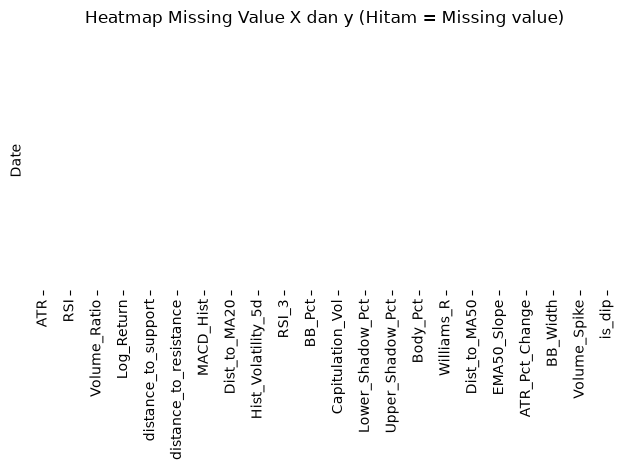

In [4]:
cek_missing_value(X_in_sample, y_in_sample)

## Modelling

In [5]:
summary_reports = []
clean_ticker = TICKER.split('.')[0].lower()

for target in TARGET_NAME:
    print(f"\n==================================================")
    print(f"MENCARI MODEL TERBAIK VARIABEL TARGET: {target.upper()}")
    print(f"==================================================")

    # Buat list untuk menampung hasil metrik semua model untuk target ini
    target_metrics_results = []
    trained_pipelines = {}
    
    # 1. Latih & Tuning Baseline
    print("[1] Menyetel Baseline Model (DummyClassifier)...")
    pipeline_bl = ModellingPipeline(target_name=target, feature_cols=FEATURES)
    X_bl, y_bl = pipeline_bl.prepare_data(df_in_sample)
    pipeline_bl.tune_and_fit(X_bl, y_bl, CLASSIFIER_BASELINE_CONFIG['model_object'], CLASSIFIER_BASELINE_CONFIG['grid_params'])

    # Simpan metrik baseline
    bl_metrics = pipeline_bl.metrics.copy()
    bl_metrics['Model'] = CLASSIFIER_BASELINE_CONFIG['name']
    target_metrics_results.append(bl_metrics)

    trained_pipelines[CLASSIFIER_BASELINE_CONFIG['name']] = pipeline_bl

    # 2. Latih & Tuning Model Tandingan
    for model_name in MODELS_NAME:
        if model_name == 'poisson_regression' and target not in ['days_to_max', 'days_to_min']:
            print(f"[-] Melewati {model_name} untuk target '{target.upper()}' (Tidak kompatibel dengan nilai negatif).")
            continue
        
        model = CLASSIFIER_CONFIGS[model_name]
        print(f"[{MODELS_NAME.index(model_name)+2}] Menyetel Model Pilihan ({model['model_object'].__class__.__name__} | {model_name})...")
        pipeline_choice = ModellingPipeline(target_name=target, feature_cols=FEATURES)
        X_c, y_c = pipeline_choice.prepare_data(df_in_sample)
        pipeline_choice.tune_and_fit(X_c, y_c, model['model_object'], model['grid_params'])

        # Simpan metrik model
        mod_metrics = pipeline_choice.metrics.copy()
        mod_metrics['Model'] = model_name
        target_metrics_results.append(mod_metrics)

        trained_pipelines[model_name] = pipeline_choice

    # 3. Evaluasi & Pemilihan Model Terbaik
    df_results = pd.DataFrame(target_metrics_results)
    
    evaluator = ModelEvaluator(target_name=target, baseline_name=CLASSIFIER_BASELINE_CONFIG['name'])
    report_dict = evaluator.generate_evaluation_report(df_results)
    summary_reports.append(report_dict)

    best_model_name = report_dict['Model Terpilih']
    best_pipeline = trained_pipelines[best_model_name]
    best_pipeline.save(folder_path="../models", ticker=clean_ticker)
    print(f">> Model '{best_model_name}' berhasil disimpan untuk target '{target}'.")
    print(f"")

# Tampilkan Laporan Visual Side-by-Side
print("\n" + "="*20 + " LAPORAN EVALUASI & OVERFIT DETECTOR " + "="*20)
df_report = pd.DataFrame(summary_reports)
print(df_report.to_string(index=False))



MENCARI MODEL TERBAIK VARIABEL TARGET: IS_DIP
[1] Menyetel Baseline Model (DummyClassifier)...
   -> [HYPERPARAMETERS]: {}
   -> [LABEL DIST]: 182/2159 positif (8.4%)
   -> [TRAIN]: Precision 8.24% | Recall 8.24% | F1 8.24%
   -> [VAL F1]: 9.59%
[2] Menyetel Model Pilihan (XGBClassifier | xgb_classifier)...
   -> [HYPERPARAMETERS]: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 5}
   -> [LABEL DIST]: 182/2159 positif (8.4%)
   -> [TRAIN]: Precision 82.42% | Recall 82.42% | F1 82.42%
   -> [VAL F1]: 9.93%
[3] Menyetel Model Pilihan (LGBMClassifier | lgbm_classifier)...
   -> [HYPERPARAMETERS]: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 5}
   -> [LABEL DIST]: 182/2159 positif (8.4%)
   -> [TRAIN]: Precision 75.61% | Recall 85.16% | F1 80.10%
   -> [VAL F1]: 11.16%
[4] Menyetel Model Pilihan (RandomForestClassifier | rf_classifier)...


c:\Users\YOGA\Downloads\Gagah Personal\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   -> [HYPERPARAMETERS]: {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 100}
   -> [LABEL DIST]: 182/2159 positif (8.4%)
   -> [TRAIN]: Precision 28.60% | Recall 88.46% | F1 43.22%
   -> [VAL F1]: 13.49%
[5] Menyetel Model Pilihan (SVC | svc)...


c:\Users\YOGA\Downloads\Gagah Personal\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


   -> [HYPERPARAMETERS]: {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
   -> [LABEL DIST]: 182/2159 positif (8.4%)
   -> [TRAIN]: Precision 15.28% | Recall 72.53% | F1 25.24%
   -> [VAL F1]: 17.84%
[SAVED] Berhasil mengekspor model classifier ke: ../models/medc/model_is_dip_medc.pkl
>> Model 'svc' berhasil disimpan untuk target 'is_dip'.


==================== LAPORAN EVALUASI & OVERFIT DETECTOR ====================
Target Baseline Val_F1 Challenger Model Challenger Val_F1 Challenger Precision Challenger Recall            Keputusan Model Terpilih  Fit Status                                                                                      Alasan Pemilihan
is_dip           9.59%              svc            17.84%               15.28%            72.53% Lolos (Awas Overfit)            svc Overfitting Semua model berstatus Overfit. Memaksa memilih model peringkat ke-1 sebagai fallback (Harap waspada).
